<a href="https://colab.research.google.com/github/faguilarleal/lab10_vision/blob/main/Task_2_A.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# TASK 2 - PARTE A
### Modelo Estándar - Costoso

In [1]:
!pip install -q diffusers transformers accelerate safetensors

import torch
import time
import pandas as pd
import matplotlib.pyplot as plt

from diffusers import StableDiffusionPipeline

Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.
Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.


# Config

In [2]:
MODEL_ID = "runwayml/stable-diffusion-v1-5"

prompt = "A highly detailed cinematic and futuristic fruit glowing in a cyberpunk laboratory, neon lights, 4k resolution"

seed = 42

device = "cuda" if torch.cuda.is_available() else "cpu"

# Cargar Modelo

In [3]:
pipe = StableDiffusionPipeline.from_pretrained(
    MODEL_ID,
    torch_dtype=torch.float16
)

pipe = pipe.to(device)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


model_index.json:   0%|          | 0.00/541 [00:00<?, ?B/s]

Fetching 15 files:   0%|          | 0/15 [00:00<?, ?it/s]

Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/196 [00:00<?, ?it/s]

CLIPTextModel LOAD REPORT from: /root/.cache/huggingface/hub/models--runwayml--stable-diffusion-v1-5/snapshots/451f4fe16113bff5a5d2269ed5ad43b0592e9a14/text_encoder
Key                                | Status     |  | 
-----------------------------------+------------+--+-
text_model.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loading weights:   0%|          | 0/396 [00:00<?, ?it/s]

StableDiffusionSafetyChecker LOAD REPORT from: /root/.cache/huggingface/hub/models--runwayml--stable-diffusion-v1-5/snapshots/451f4fe16113bff5a5d2269ed5ad43b0592e9a14/safety_checker
Key                                               | Status     |  | 
--------------------------------------------------+------------+--+-
vision_model.vision_model.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


# Medición de rendimiento

In [4]:
torch.cuda.empty_cache()
torch.cuda.reset_peak_memory_stats()

generator = torch.manual_seed(seed)

start_time = time.time()

# Generación 50 pasos

In [5]:
result = pipe(
    prompt,
    num_inference_steps=50,
    generator=generator
)

end_time = time.time()


  0%|          | 0/50 [00:00<?, ?it/s]

# Metricas

In [6]:
execution_time = end_time - start_time

max_vram_bytes = torch.cuda.max_memory_allocated()
max_vram_gb = max_vram_bytes / (1024**3)

image = result.images[0]

image.save("task2_standard_model.png")

# Resultados

========== RESULTADOS ==========
Modelo: Stable Diffusion v1.5
Pasos de inferencia: 50
Tiempo de ejecución: 10.39 segundos
VRAM maxima utilizada: 3.18 GB


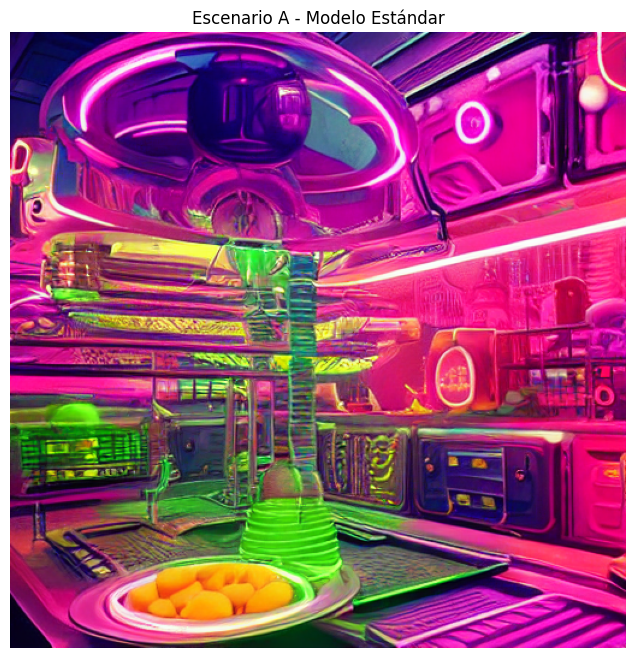

In [7]:
print("========== RESULTADOS ==========")
print(f"Modelo: Stable Diffusion v1.5")
print(f"Pasos de inferencia: 50")
print(f"Tiempo de ejecución: {execution_time:.2f} segundos")
print(f"VRAM maxima utilizada: {max_vram_gb:.2f} GB")


plt.figure(figsize=(8,8))
plt.imshow(image)
plt.axis("off")
plt.title("Escenario A - Modelo Estándar")
plt.show()

In [8]:
results_df = pd.DataFrame({
    "Modelo": ["Stable Diffusion v1.5"],
    "Pasos": [50],
    "Tiempo (s)": [round(execution_time, 2)],
    "VRAM (GB)": [round(max_vram_gb, 2)]
})

display(results_df)

,Modelo,Pasos,Tiempo (s),VRAM (GB)
0,Stable Diffusion v1.5,50,10.39,3.18
